In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# 1. Load TSV files (they have no headers, sep is Tab)
cols = ['id', 'label', 'statement', 'subject', 'speaker', 'job', 'state', 'party', 'barely', 'false', 'half', 'mostly', 'pants', 'context']

train_df = pd.read_csv('train.tsv', sep='\t', header=None, names=cols)
test_df = pd.read_csv('test.tsv', sep='\t', header=None, names=cols)
valid_df = pd.read_csv('valid.tsv', sep='\t', header=None, names=cols)

# 2. Binary Mapping
# Real = 0 (true, mostly-true, half-true)
# Fake = 1 (barely-true, false, pants-on-fire)
label_dict = {
    'true': 0, 'mostly-true': 0, 'half-true': 0,
    'barely-true': 1, 'false': 1, 'pants-fire': 1
}

train_df['target'] = train_df['label'].map(label_dict)
test_df['target'] = test_df['label'].map(label_dict)

# 3. Prepare X and y
X_train, y_train = train_df['statement'].astype(str), train_df['target']
X_test, y_test = test_df['statement'].astype(str), test_df['target']

final_results = {}

# Performance Function
def evaluate(y_true, y_probs, name):
    y_pred = (y_probs > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    final_results[name] = acc
    print(f"\n--- {name} Accuracy: {acc*100:.2f}% ---")

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Purples', ax=ax[0])
    ax[0].set_title(f"Confusion: {name}")

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    ax[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
    ax[1].plot([0,1],[0,1], '--')
    ax[1].set_title(f"ROC: {name}")
    plt.legend()
    plt.show()


--- Naive Bayes Accuracy: 60.77% ---


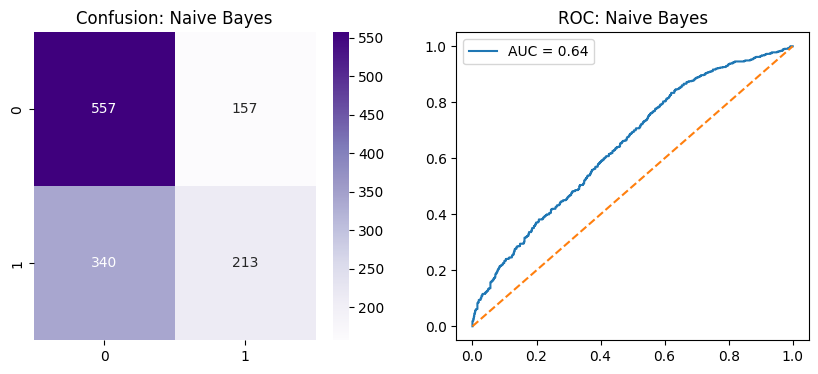


--- SVM Accuracy: 61.33% ---


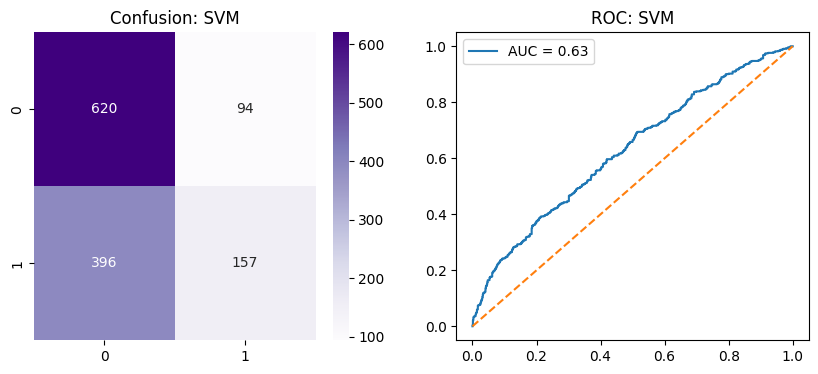

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 1. Naive Bayes
nb = MultinomialNB().fit(X_train_vec, y_train)
evaluate(y_test, nb.predict_proba(X_test_vec)[:, 1], "Naive Bayes")

# 2. SVM
svm = CalibratedClassifierCV(LinearSVC()).fit(X_train_vec, y_train)
evaluate(y_test, svm.predict_proba(X_test_vec)[:, 1], "SVM")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5839 - loss: 0.6707
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6881 - loss: 0.5958
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7621 - loss: 0.4995
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8157 - loss: 0.4109
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8595 - loss: 0.3260
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

--- LSTM Accuracy: 57.38% ---


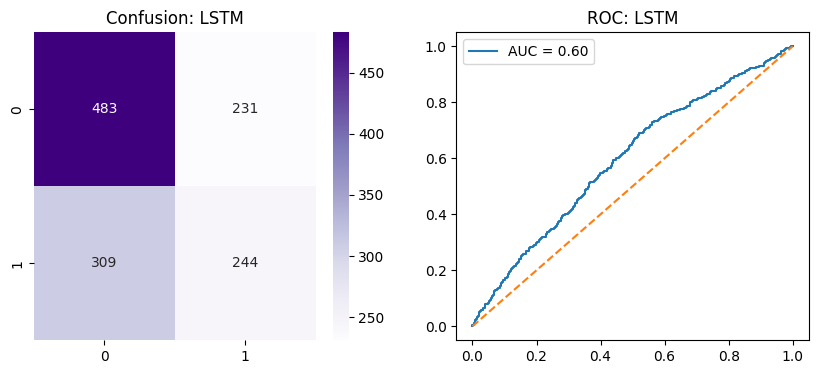

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

tok = Tokenizer(num_words=5000)
tok.fit_on_texts(X_train)
X_train_pad = pad_sequences(tok.texts_to_sequences(X_train), maxlen=40)
X_test_pad = pad_sequences(tok.texts_to_sequences(X_test), maxlen=40)

lstm = Sequential([
    Embedding(5000, 64, input_length=40),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm.fit(X_train_pad, y_train, epochs=5, batch_size=32, verbose=1)

evaluate(y_test, lstm.predict(X_test_pad).flatten(), "LSTM")